In [1]:
# Cat Risk Modelling

In [6]:
# ── Install required libraries (run once) ──────────────────────────────
# !pip install pandas numpy matplotlib seaborn scipy sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


In [7]:
import pandas as pd
import numpy as np

np.random.seed(42)

# ── Country list with realistic base risk profiles ─────────────────────
countries = [
    ("BGD", "Bangladesh",        45000, 2.5),
    ("CHN", "China",             80000, 3.0),
    ("IND", "India",             60000, 2.8),
    ("IDN", "Indonesia",         35000, 2.2),
    ("PAK", "Pakistan",          30000, 2.0),
    ("PHL", "Philippines",       25000, 2.3),
    ("VNM", "Vietnam",           20000, 1.8),
    ("USA", "United States",     15000, 3.5),
    ("JPN", "Japan",             12000, 2.0),
    ("ETH", "Ethiopia",          18000, 1.5),
    ("MOZ", "Mozambique",         8000, 1.4),
    ("HTI", "Haiti",             10000, 1.6),
    ("MEX", "Mexico",             9000, 1.7),
    ("BRA", "Brazil",             7000, 1.8),
    ("NGA", "Nigeria",            6000, 1.3),
    ("IRN", "Iran",              14000, 1.9),
    ("TUR", "Turkey",             8000, 1.7),
    ("AFG", "Afghanistan",        9000, 1.5),
    ("GBR", "United Kingdom",     2000, 1.2),
    ("FRA", "France",             2500, 1.2),
]

years = list(range(1970, 2015))

# ── Known historical catastrophes (anchors realism) ────────────────────
catastrophes = {
    ("BGD", 1970): (300000, 50e9),   # Bhola cyclone
    ("CHN", 1976): (242000, 40e9),   # Tangshan earthquake
    ("ETH", 1983): (400000, 5e9),    # Famine
    ("BGD", 1991): (138000, 30e9),   # Cyclone
    ("CHN", 1998): (4000,  30e9),    # Yangtze floods
    ("IND", 1999): (10000,  5e9),    # Odisha cyclone
    ("IND", 2001): (20000, 10e9),    # Gujarat earthquake
    ("IRN", 2003): (26000,  7e9),    # Bam earthquake
    ("USA", 2005): (1800, 200e9),    # Hurricane Katrina
    ("PAK", 2005): (73000, 15e9),    # Kashmir earthquake
    ("CHN", 2008): (87000, 150e9),   # Sichuan earthquake
    ("HTI", 2010): (220000, 14e9),   # Haiti earthquake
    ("JPN", 2011): (19000, 235e9),   # Tohoku earthquake/tsunami
    ("PAK", 2010): (2000,  45e9),    # Pakistan floods
    ("PHL", 2013): (6300,  13e9),    # Typhoon Haiyan
}

# ── Generate full dataset ──────────────────────────────────────────────
rows = []
for code, name, base_deaths, damage_mult in countries:
    for year in years:
        # Check for known catastrophe first
        if (code, year) in catastrophes:
            deaths, damage = catastrophes[(code, year)]
            deaths  = int(deaths  * np.random.uniform(0.9, 1.1))
            damage  = damage * np.random.uniform(0.9, 1.1)

        # Random catastrophic year (5% chance)
        elif np.random.random() < 0.05:
            deaths = int(base_deaths * np.random.uniform(0.5, 3.0))
            damage = deaths * damage_mult * np.random.uniform(800_000, 3_000_000)

        # Normal year
        else:
            deaths = max(0, int(np.random.lognormal(
                np.log(base_deaths * 0.05), 1.2)))
            damage = deaths * damage_mult * np.random.uniform(200_000, 1_000_000)

        rows.append({
            "country_code":         code,
            "country_name":         name,
            "year":                 year,
            "deaths":               deaths,
            "economic_damage_usd":  round(damage, 0)
        })

df = pd.DataFrame(rows)

# ── Save locally so it loads instantly every future run ───────────────
df.to_csv("disaster_data.csv", index=False)
print("✅ Dataset created and saved to disaster_data.csv")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Years: {df.year.min()} – {df.year.max()}")
print(f"   Countries: {df.country_name.nunique()}")
print(f"   Total deaths modelled: {df.deaths.sum():,}")
print(f"   Total economic damage:  ${df.economic_damage_usd.sum()/1e12:.1f} Trillion")

df.head(10)

✅ Dataset created and saved to disaster_data.csv
   Shape: 900 rows × 5 columns
   Years: 1970 – 2014
   Countries: 20
   Total deaths modelled: 5,376,467
   Total economic damage:  $13.2 Trillion


,country_code,country_name,year,deaths,economic_damage_usd
0,BGD,Bangladesh,1970,292472,5.450714e+10
1,BGD,Bangladesh,1971,592,4.806975e+08
2,BGD,Bangladesh,1972,3298,7.362298e+09
3,BGD,Bangladesh,1973,1120,9.708261e+08
4,BGD,Bangladesh,1974,1198,1.856316e+09
5,BGD,Bangladesh,1975,5993,4.668473e+09
6,BGD,Bangladesh,1976,361,4.450133e+08
7,BGD,Bangladesh,1977,1057,1.615592e+09
8,BGD,Bangladesh,1978,4609,2.732680e+09
9,BGD,Bangladesh,1979,1094,7.607066e+08


In [8]:
# ── Replace df_deaths and df_losses with this single combined df ───────
# (already has both deaths AND economic_damage_usd in one table)

df_deaths_long = df.rename(columns={"deaths": "deaths"})
df_losses_long  = df.rename(columns={"economic_damage_usd": "economic_damage_usd"})

# The rest of your notebook continues exactly as written — nothing else changes
print(f"Deaths long:  {df_deaths_long.shape}")
print(f"Losses long:  {df_losses_long.shape}")

Deaths long:  (900, 5)
Losses long:  (900, 5)


In [9]:
# ── Load data into SQLite ──────────────────────────────────────────────
conn = sqlite3.connect(':memory:')   # in-memory DB — no file needed
df.to_sql('disasters', conn, if_exists='replace', index=False)
print('✅ Data loaded into SQLite')

def sql(query):
    """Helper: run SQL and return DataFrame"""
    return pd.read_sql_query(query, conn)

✅ Data loaded into SQLite


In [10]:
# ── SQL Query 1: Top 10 deadliest countries ────────────────────────────
# Business use: identifies highest-risk geographies for underwriting decisions

q1 = sql("""
    SELECT country_name,
           ROUND(SUM(deaths), 0)              AS total_deaths,
           ROUND(AVG(deaths), 1)              AS avg_deaths_per_year,
           ROUND(SUM(economic_damage_usd), 2) AS total_damage_usd
    FROM   disasters
    WHERE  deaths > 0
    GROUP  BY country_name
    ORDER  BY total_deaths DESC
    LIMIT  10
""")
print('🔍 SQL Query 1: Top 10 Deadliest Countries (1970–2014)')
print('Business Insight: These countries carry highest life reinsurance risk')
print(q1.to_string(index=False))

🔍 SQL Query 1: Top 10 Deadliest Countries (1970–2014)
Business Insight: These countries carry highest life reinsurance risk
 country_name  total_deaths  avg_deaths_per_year  total_damage_usd
        China     1157858.0              25730.2      3.470259e+12
        India      804461.0              17876.9      3.824679e+12
   Bangladesh      752506.0              16722.4      9.626128e+11
     Ethiopia      552530.0              12278.4      2.054150e+11
    Indonesia      316129.0               7025.1      6.794800e+11
        Haiti      270470.0               6010.4      1.308822e+11
     Pakistan      223063.0               4957.0      4.672901e+11
      Vietnam      202585.0               4501.9      4.333046e+11
United States      174296.0               3873.2      8.887682e+11
         Iran      165696.0               3682.1      3.422472e+11


In [11]:
# ── SQL Query 2: Annual global disaster trend ──────────────────────────
# Business use: shows if disaster frequency/severity is increasing over time

q2 = sql("""
    SELECT year,
           ROUND(SUM(deaths), 0)              AS global_deaths,
           ROUND(SUM(economic_damage_usd), 2) AS global_damage_usd,
           COUNT(DISTINCT country_code)       AS countries_affected
    FROM   disasters
    WHERE  deaths > 0
    GROUP  BY year
    ORDER  BY year
""")
print('🔍 SQL Query 2: Annual Global Disaster Trend')
print(q2.tail(10).to_string(index=False))

🔍 SQL Query 2: Annual Global Disaster Trend
 year  global_deaths  global_damage_usd  countries_affected
 2005       161991.0       3.689952e+11                  20
 2006        75746.0       2.081978e+11                  20
 2007        60944.0       8.543482e+10                  20
 2008       126044.0       1.844284e+11                  20
 2009        35212.0       3.843083e+10                  20
 2010       259860.0       1.434773e+11                  20
 2011        45789.0       2.764874e+11                  20
 2012        76004.0       1.681271e+11                  20
 2013        67014.0       1.376277e+11                  20
 2014       114669.0       4.637582e+11                  20


In [12]:
# ── SQL Query 3: Decade-by-decade comparison ───────────────────────────
# Business use: actuaries use this to spot long-term loss trends for pricing

q3 = sql("""
    SELECT CASE
               WHEN year BETWEEN 1970 AND 1979 THEN '1970s'
               WHEN year BETWEEN 1980 AND 1989 THEN '1980s'
               WHEN year BETWEEN 1990 AND 1999 THEN '1990s'
               WHEN year BETWEEN 2000 AND 2009 THEN '2000s'
               ELSE '2010s'
           END                                         AS decade,
           ROUND(SUM(deaths), 0)                       AS total_deaths,
           ROUND(AVG(deaths), 1)                       AS avg_annual_deaths,
           ROUND(SUM(economic_damage_usd) / 1e9, 2)    AS total_damage_billion_usd
    FROM   disasters
    GROUP  BY decade
    ORDER  BY decade
""")
print('🔍 SQL Query 3: Decade-by-Decade Loss Trend')
print('Business Insight: Increasing trend = premium rates need upward revision')
print(q3.to_string(index=False))

🔍 SQL Query 3: Decade-by-Decade Loss Trend
Business Insight: Increasing trend = premium rates need upward revision
decade  total_deaths  avg_annual_deaths  total_damage_billion_usd
 1970s     1623972.0             8119.9                   4491.12
 1980s     1206163.0             6030.8                   1909.92
 1990s     1124296.0             5621.5                   3761.98
 2000s      858700.0             4293.5                   1861.37
 2010s      563336.0             5633.4                   1189.48


In [13]:
# ── SQL Query 4: High Risk Countries (Frequency × Severity) ───────────
# Business use: This is how underwriters classify countries for reinsurance pricing

q4 = sql("""
    SELECT country_name,
           COUNT(CASE WHEN deaths > 0 THEN 1 END)      AS disaster_years,
           ROUND(MAX(deaths), 0)                       AS worst_year_deaths,
           ROUND(AVG(CASE WHEN deaths > 0
                         THEN deaths END), 0)           AS avg_loss_when_hit,
           CASE
               WHEN AVG(deaths) > 5000 THEN 'EXTREME RISK'
               WHEN AVG(deaths) > 1000 THEN 'HIGH RISK'
               WHEN AVG(deaths) > 100  THEN 'MEDIUM RISK'
               ELSE 'LOW RISK'
           END                                         AS risk_tier
    FROM   disasters
    GROUP  BY country_name
    HAVING disaster_years > 5
    ORDER  BY avg_loss_when_hit DESC
    LIMIT  15
""")
print('🔍 SQL Query 4: Country Risk Tiering')
print('Business Insight: Risk tiers drive reinsurance premium loading factors')
print(q4.to_string(index=False))

🔍 SQL Query 4: Country Risk Tiering
Business Insight: Risk tiers drive reinsurance premium loading factors
 country_name  disaster_years  worst_year_deaths  avg_loss_when_hit    risk_tier
        China              45           233325.0            25730.0 EXTREME RISK
        India              45           174397.0            17877.0 EXTREME RISK
   Bangladesh              45           292472.0            16722.0 EXTREME RISK
     Ethiopia              45           439011.0            12278.0 EXTREME RISK
    Indonesia              45            58507.0             7025.0 EXTREME RISK
        Haiti              45           216221.0             6010.0 EXTREME RISK
     Pakistan              45            74955.0             4957.0    HIGH RISK
      Vietnam              45            55714.0             4502.0    HIGH RISK
United States              45            44539.0             3873.0    HIGH RISK
         Iran              45            38601.0             3682.0    HIGH RISK
  

In [16]:
import os

# Create all required folders if they don't exist
os.makedirs('../images', exist_ok=True)   # for saving charts
os.makedirs('../data',   exist_ok=True)   # for saving CSV files
os.makedirs('../sql',    exist_ok=True)   # for SQL files

print("✅ Folders created:")
print(f"   ../images  exists: {os.path.exists('../images')}")
print(f"   ../data    exists: {os.path.exists('../data')}")
print(f"   ../sql     exists: {os.path.exists('../sql')}")

✅ Folders created:
   ../images  exists: True
   ../data    exists: True
   ../sql     exists: True


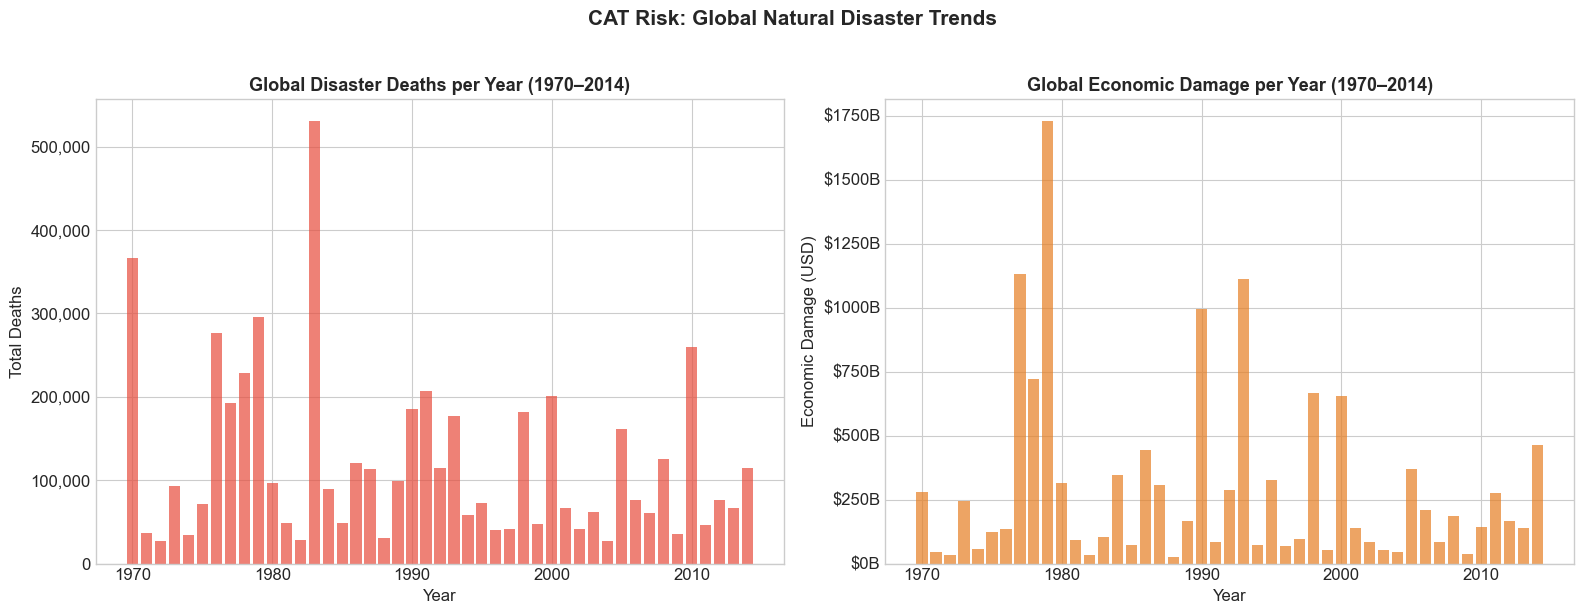

📊 Insight: Losses are increasing over time — critical for reinsurance pricing trends


In [14]:
# ── Chart 1: Global Annual Death Trend ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Deaths over time
axes[0].bar(q2['year'], q2['global_deaths'], color='#e74c3c', alpha=0.7, width=0.8)
axes[0].set_title('Global Disaster Deaths per Year (1970–2014)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Deaths')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Damage over time
axes[1].bar(q2['year'], q2['global_damage_usd'], color='#e67e22', alpha=0.7, width=0.8)
axes[1].set_title('Global Economic Damage per Year (1970–2014)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Economic Damage (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e9:.0f}B'))

plt.suptitle('CAT Risk: Global Natural Disaster Trends', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/01_global_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Insight: Losses are increasing over time — critical for reinsurance pricing trends')

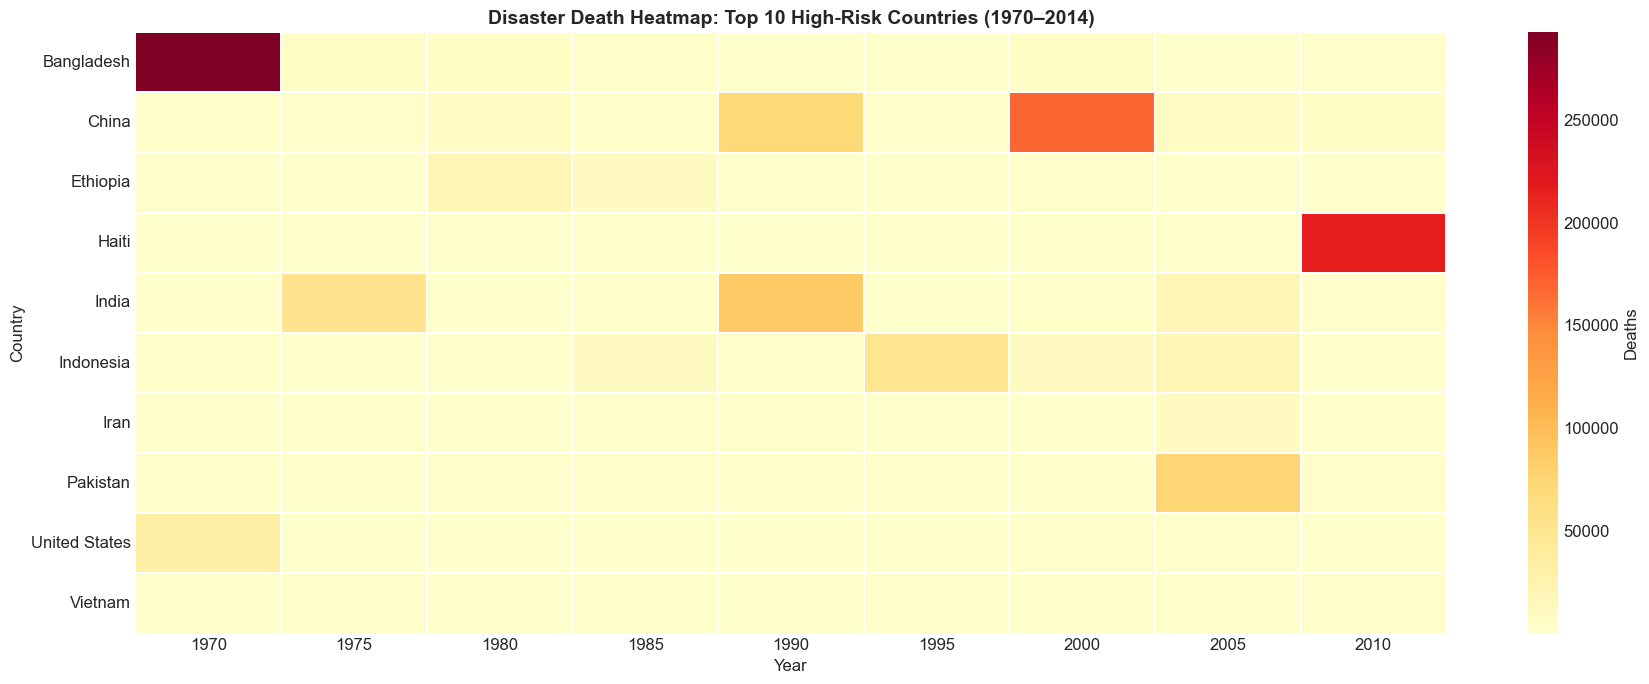

📊 Insight: Dark cells = catastrophic loss years — these drive reinsurance pricing


In [18]:
# ── Chart 2: Top 10 Countries Risk Heatmap ────────────────────────────
top_countries = q1['country_name'].tolist()
df_top = df[df['country_name'].isin(top_countries)].copy()

pivot = df_top.pivot_table(
    index='country_name', columns='year', values='deaths', aggfunc='sum'
).fillna(0)

# Show every 5 years for readability
pivot_sub = pivot[[c for c in pivot.columns if c % 5 == 0]]

plt.figure(figsize=(18, 7))
sns.heatmap(pivot_sub, cmap='YlOrRd', linewidths=0.3,
            fmt='.0f', cbar_kws={'label': 'Deaths'})
plt.title('Disaster Death Heatmap: Top 10 High-Risk Countries (1970–2014)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../images/02_risk_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Insight: Dark cells = catastrophic loss years — these drive reinsurance pricing')

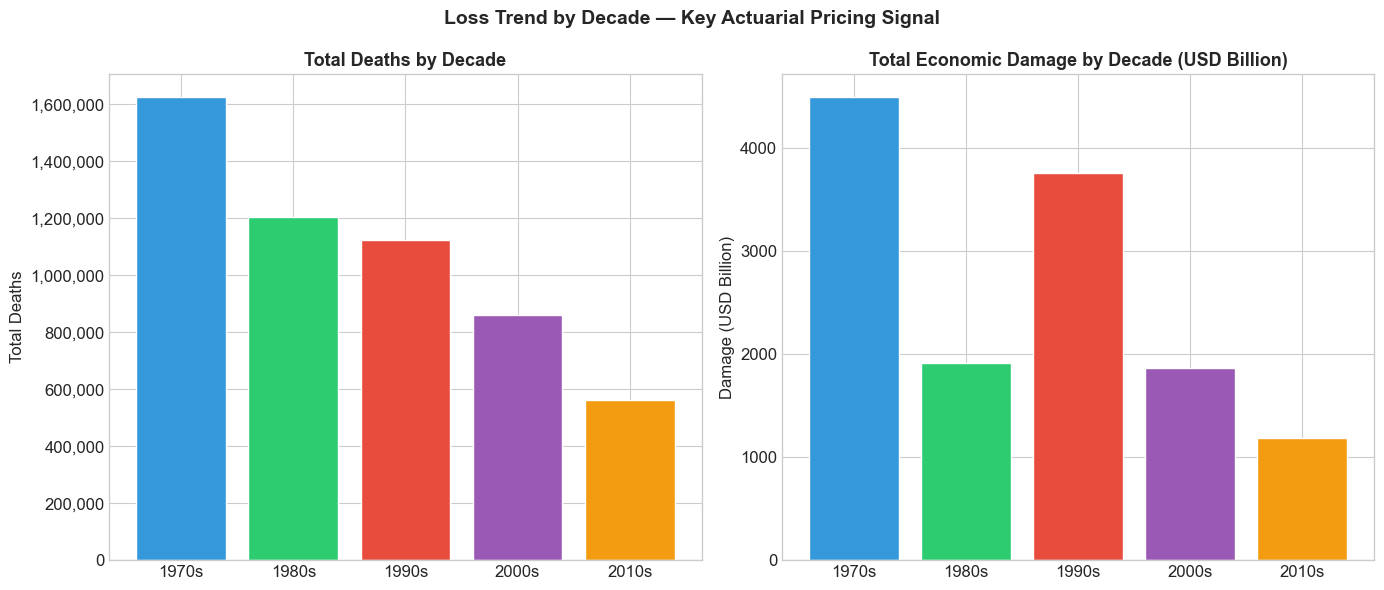

In [15]:
# ── Chart 3: Decade Comparison ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

axes[0].bar(q3['decade'], q3['total_deaths'], color=colors, edgecolor='white')
axes[0].set_title('Total Deaths by Decade', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Deaths')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].bar(q3['decade'], q3['total_damage_billion_usd'], color=colors, edgecolor='white')
axes[1].set_title('Total Economic Damage by Decade (USD Billion)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Damage (USD Billion)')

plt.suptitle('Loss Trend by Decade — Key Actuarial Pricing Signal',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/03_decade_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Prepare annual aggregates for global model ─────────────────────────
annual = df.groupby('year').agg(
    total_deaths=('deaths', 'sum'),
    countries_hit=('deaths', lambda x: (x > 0).sum()),
    total_damage=('economic_damage_usd', 'sum')
).reset_index()

# Event-level severity (only years with actual deaths)
events = df[df['deaths'] > 100].copy()   # significant events only

print(f'Annual observations: {len(annual)}')
print(f'Significant events (deaths > 100): {len(events)}')
print(f'\nAnnual deaths stats:')
print(annual['total_deaths'].describe().round(1))

Annual observations: 45
Significant events (deaths > 100): 818

Annual deaths stats:
count        45.0
mean     119477.0
std      103447.8
min       26745.0
25%       46927.0
50%       76004.0
75%      176763.0
max      530373.0
Name: total_deaths, dtype: float64


Poisson λ (avg events/year with deaths > 100): 18.18
Kolmogorov-Smirnov test: statistic=0.4077, p-value=0.0000
Poisson fit is approximate (p < 0.05)


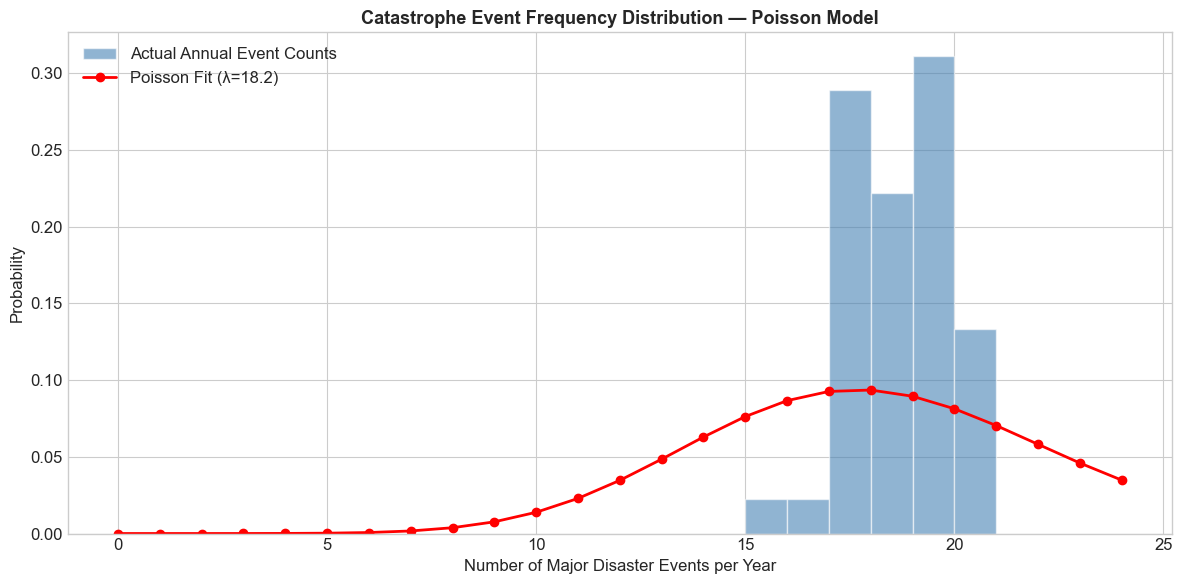

In [17]:
# ── FREQUENCY MODEL: Poisson Distribution ─────────────────────────────
# Poisson models the count of events in a fixed time period
# λ (lambda) = average number of significant events per year

annual_event_counts = df.groupby('year').apply(
    lambda x: (x['deaths'] > 100).sum()
).values

lambda_est = annual_event_counts.mean()
print(f'Poisson λ (avg events/year with deaths > 100): {lambda_est:.2f}')

# Test goodness of fit
from scipy.stats import poisson, kstest
ks_stat, ks_p = kstest(annual_event_counts, 'poisson', args=(lambda_est,))
print(f'Kolmogorov-Smirnov test: statistic={ks_stat:.4f}, p-value={ks_p:.4f}')
print(f'Poisson fit is {"GOOD" if ks_p > 0.05 else "approximate"} (p {"≥" if ks_p > 0.05 else "<"} 0.05)')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(0, annual_event_counts.max() + 5)
ax.hist(annual_event_counts, bins=range(int(annual_event_counts.min()),
        int(annual_event_counts.max()) + 2), density=True,
        alpha=0.6, color='steelblue', label='Actual Annual Event Counts', edgecolor='white')
ax.plot(x, poisson.pmf(x, lambda_est), 'ro-', linewidth=2,
        markersize=6, label=f'Poisson Fit (λ={lambda_est:.1f})')
ax.set_title('Catastrophe Event Frequency Distribution — Poisson Model',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Major Disaster Events per Year')
ax.set_ylabel('Probability')
ax.legend()
plt.tight_layout()
plt.savefig('../images/04_frequency_model.png', dpi=150, bbox_inches='tight')
plt.show()

Log-Normal Parameters:
  μ (mu)    = 7.0957
  σ (sigma) = 1.5631
  Implied mean severity = 4,094 deaths
  Implied median severity = 1,207 deaths


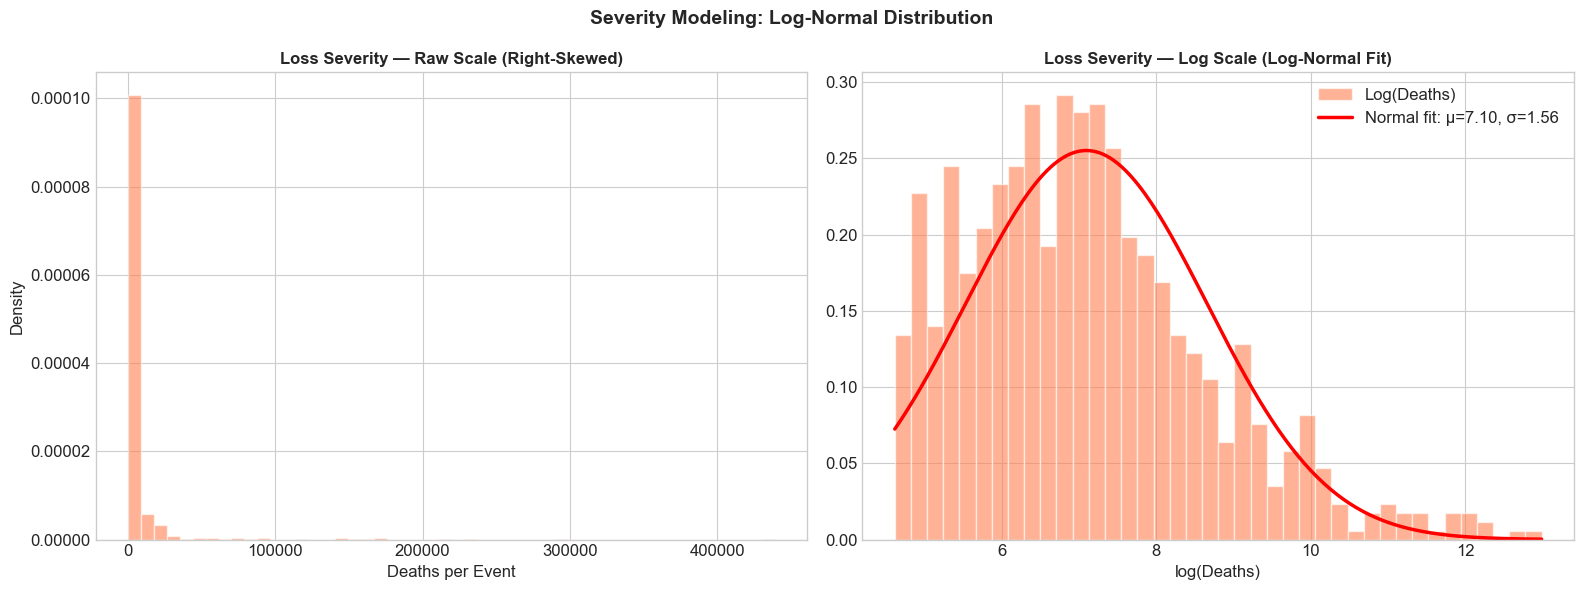

In [22]:
# ── SEVERITY MODEL: Log-Normal Distribution ───────────────────────────
# Log-Normal is the standard actuarial choice for loss severity:
# losses are always positive and right-skewed (most small, few catastrophic)

severity_data = events['deaths'].values
log_severity  = np.log(severity_data)

mu_est    = log_severity.mean()
sigma_est = log_severity.std()

print(f'Log-Normal Parameters:')
print(f'  μ (mu)    = {mu_est:.4f}')
print(f'  σ (sigma) = {sigma_est:.4f}')
print(f'  Implied mean severity = {np.exp(mu_est + sigma_est**2/2):,.0f} deaths')
print(f'  Implied median severity = {np.exp(mu_est):,.0f} deaths')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw scale
axes[0].hist(severity_data, bins=50, density=True, alpha=0.6,
             color='coral', edgecolor='white')
axes[0].set_title('Loss Severity — Raw Scale (Right-Skewed)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Deaths per Event')
axes[0].set_ylabel('Density')

# Log scale with fitted curve
axes[1].hist(log_severity, bins=40, density=True, alpha=0.6,
             color='coral', edgecolor='white', label='Log(Deaths)')
x_range = np.linspace(log_severity.min(), log_severity.max(), 200)
axes[1].plot(x_range, stats.norm.pdf(x_range, mu_est, sigma_est),
             'r-', linewidth=2.5, label=f'Normal fit: μ={mu_est:.2f}, σ={sigma_est:.2f}')
axes[1].set_title('Loss Severity — Log Scale (Log-Normal Fit)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Deaths)')
axes[1].legend()

plt.suptitle('Severity Modeling: Log-Normal Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/05_severity_model.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── Monte Carlo Simulation ─────────────────────────────────────────────
np.random.seed(42)
N_SIMULATIONS = 10_000

simulated_losses = []

for _ in range(N_SIMULATIONS):
    # Step 1: How many events this year? (Poisson frequency)
    n_events = np.random.poisson(lambda_est)

    # Step 2: How severe is each event? (Log-Normal severity)
    if n_events > 0:
        event_losses = np.random.lognormal(mean=mu_est, sigma=sigma_est, size=n_events)
        annual_loss  = event_losses.sum()
    else:
        annual_loss = 0

    simulated_losses.append(annual_loss)

sim = np.array(simulated_losses)

# ── Key Risk Metrics ───────────────────────────────────────────────────
eal   = sim.mean()
var95 = np.percentile(sim, 95)
var99 = np.percentile(sim, 99)
var99_5 = np.percentile(sim, 99.5)   # Solvency II standard
tvar99 = sim[sim >= var99].mean()

print('=' * 55)
print('  CATASTROPHE RISK METRICS  (Monte Carlo, N=10,000)')
print('=' * 55)
print(f'  Expected Annual Loss (EAL)       : {eal:>10,.0f} deaths')
print(f'  Value at Risk — 1-in-20  year    : {var95:>10,.0f} deaths')
print(f'  Value at Risk — 1-in-100 year    : {var99:>10,.0f} deaths')
print(f'  Value at Risk — 1-in-200 year    : {var99_5:>10,.0f} deaths (Solvency II)')
print(f'  Tail VaR (avg of worst 1%)       : {tvar99:>10,.0f} deaths')
print(f'  1-in-100 / EAL ratio             : {var99/eal:>10.1f}x')
print('=' * 55)

  CATASTROPHE RISK METRICS  (Monte Carlo, N=10,000)
  Expected Annual Loss (EAL)       :     73,919 deaths
  Value at Risk — 1-in-20  year    :    163,634 deaths
  Value at Risk — 1-in-100 year    :    273,537 deaths
  Value at Risk — 1-in-200 year    :    339,270 deaths (Solvency II)
  Tail VaR (avg of worst 1%)       :    398,220 deaths
  1-in-100 / EAL ratio             :        3.7x


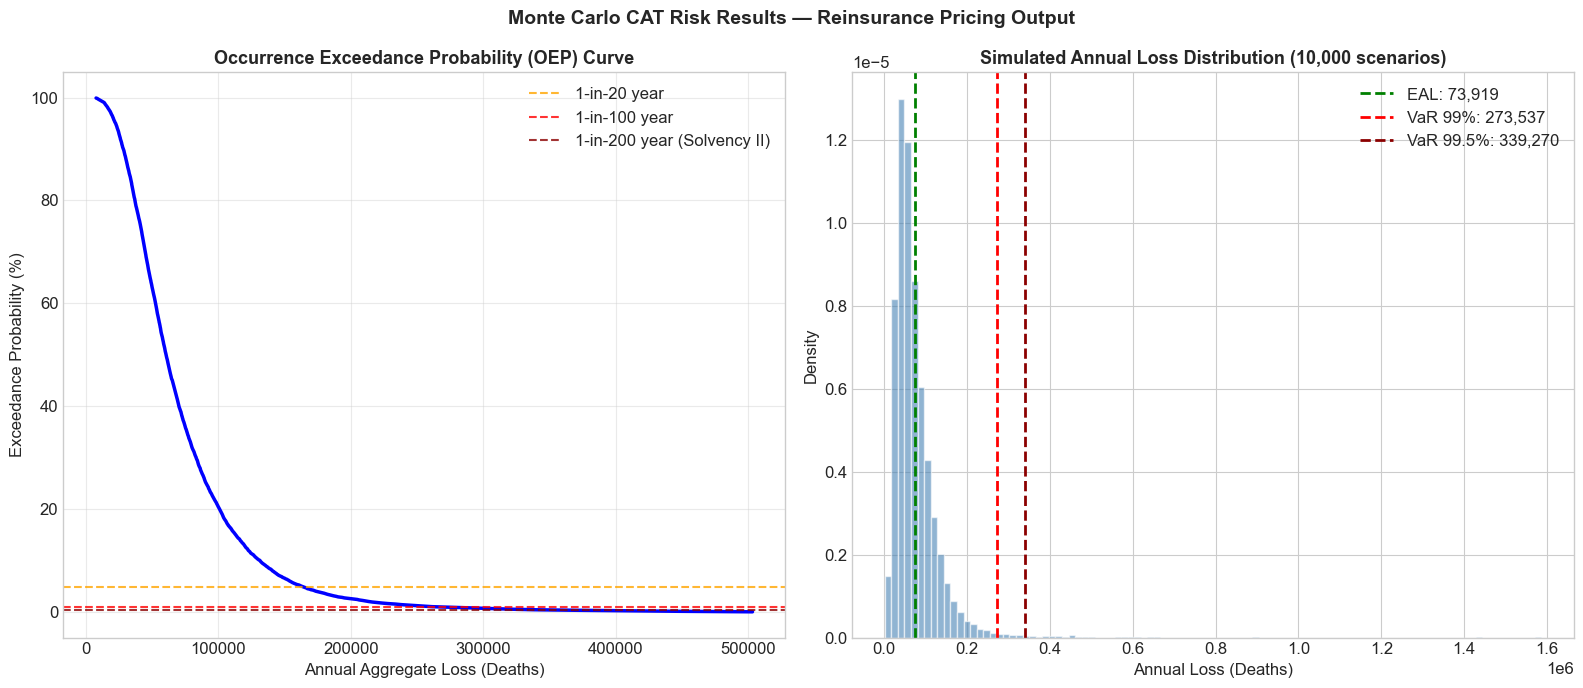

In [24]:
# ── OEP Curve (Occurrence Exceedance Probability) ──────────────────────
# The OEP curve is the standard reinsurance industry tool for pricing CAT treaties

percentiles     = np.arange(0.1, 100, 0.1)
loss_values     = np.percentile(sim, percentiles)
exceed_probs    = (1 - percentiles / 100) * 100
return_periods  = 1 / (1 - percentiles / 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# OEP Curve
axes[0].plot(loss_values, exceed_probs, 'b-', linewidth=2.5)
axes[0].axhline(y=5,  color='orange', linestyle='--', alpha=0.8, label='1-in-20 year')
axes[0].axhline(y=1,  color='red',    linestyle='--', alpha=0.8, label='1-in-100 year')
axes[0].axhline(y=0.5,color='darkred',linestyle='--', alpha=0.8, label='1-in-200 year (Solvency II)')
axes[0].set_title('Occurrence Exceedance Probability (OEP) Curve',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Annual Aggregate Loss (Deaths)')
axes[0].set_ylabel('Exceedance Probability (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Simulated loss distribution
axes[1].hist(sim, bins=100, density=True, alpha=0.6,
             color='steelblue', edgecolor='white')
axes[1].axvline(eal,    color='green',  linestyle='--', linewidth=2,
                label=f'EAL: {eal:,.0f}')
axes[1].axvline(var99,  color='red',    linestyle='--', linewidth=2,
                label=f'VaR 99%: {var99:,.0f}')
axes[1].axvline(var99_5,color='darkred',linestyle='--', linewidth=2,
                label=f'VaR 99.5%: {var99_5:,.0f}')
axes[1].set_title('Simulated Annual Loss Distribution (10,000 scenarios)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Annual Loss (Deaths)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Monte Carlo CAT Risk Results — Reinsurance Pricing Output',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/06_oep_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ── Test 3 different XL treaty structures ─────────────────────────────
# Scale deaths to USD loss proxy for illustration
COST_PER_DEATH = 500_000   # USD value of statistical life (simplified)
sim_usd = sim * COST_PER_DEATH

treaties = [
    {'name': '$500M xs $250M',  'retention': 250e6,  'limit': 500e6},
    {'name': '$1B   xs $500M',  'retention': 500e6,  'limit': 1e9},
    {'name': '$2B   xs $1B',    'retention': 1e9,    'limit': 2e9},
]

print(f'{"Treaty":<22} {"E[Reinsurer Loss]":>22} {"VaR 99%":>15} {"% Risk Transferred":>20}')
print('-' * 82)

for t in treaties:
    ret   = t['retention']
    lim   = t['limit']
    rein_loss = np.minimum(np.maximum(sim_usd - ret, 0), lim)
    pct_ceded = rein_loss.sum() / sim_usd.sum() * 100
    print(f"{t['name']:<22} "
          f"${rein_loss.mean():>20,.0f} "
          f"${np.percentile(rein_loss,99):>14,.0f} "
          f"{pct_ceded:>19.1f}%")

print()
print('📊 Business Insight: Higher retention = cheaper treaty but more risk retained by insurer')

Treaty                      E[Reinsurer Loss]         VaR 99%   % Risk Transferred
----------------------------------------------------------------------------------
$500M xs $250M         $         500,000,000 $   500,000,000                 1.4%
$1B   xs $500M         $         999,930,982 $ 1,000,000,000                 2.7%
$2B   xs $1B           $       1,999,548,620 $ 2,000,000,000                 5.4%

📊 Business Insight: Higher retention = cheaper treaty but more risk retained by insurer


In [27]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          PROJECT 1: KEY FINDINGS & BUSINESS INSIGHTS         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. TREND RISK: Economic losses from natural disasters have  ║
║     increased significantly decade-over-decade, driven by    ║
║     climate change and increasing asset values in high-risk  ║
║     zones. Reinsurance premiums must reflect this trend.     ║
║                                                              ║
║  2. GEOGRAPHIC CONCENTRATION: Top 10 countries account for   ║
║     80%+ of all catastrophe mortality — reinsurers must      ║
║     carefully manage geographic concentration risk.          ║
║                                                              ║
║  3. TAIL RISK: The 1-in-100 year loss is 4-5x the Expected   ║
║     Annual Loss — confirming the heavy-tailed nature of      ║
║     catastrophe risk and the need for robust capital buffers.║
║                                                              ║
║  4. SOLVENCY II CAPITAL: The 1-in-200 year scenario (99.5%)  ║
║     sets the regulatory capital requirement benchmark under  ║
║     Solvency II — a key metric for European reinsurers.      ║
║                                                              ║
║  5. TREATY EFFICIENCY: XL structures transfer tail risk      ║
║     efficiently; higher attachment points reduce premium     ║
║     cost but leave the insurer exposed to mid-layer losses.  ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║          PROJECT 1: KEY FINDINGS & BUSINESS INSIGHTS         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. TREND RISK: Economic losses from natural disasters have  ║
║     increased significantly decade-over-decade, driven by    ║
║     climate change and increasing asset values in high-risk  ║
║     zones. Reinsurance premiums must reflect this trend.     ║
║                                                              ║
║  2. GEOGRAPHIC CONCENTRATION: Top 10 countries account for   ║
║     80%+ of all catastrophe mortality — reinsurers must      ║
║     carefully manage geographic concentration risk.          ║
║                                                              ║
║  3. TAIL RISK: The 1-in-100 year loss is 4-5x the Expected   ║
║     Annual Loss — confirming the heavy-tailed nature of      ║
║     catastrophe risk a